# Geographic-unit assessment — Mexico City (CDMX)

This notebook records the candidate-unit decision, profiles INEGI Marco Geoestadístico 2020 for all 16 alcaldías, maps all 2,431 urban AGEBs, runs the geography transform, and verifies point-in-polygon assignment against DENUE. Raw inputs are read-only.

## Candidate-unit decision

| Unit | Census availability | Official polygons | Shared key | Resolution | Confidentiality suppression | Decision |
|---|---|---|---|---|---|---|
| Municipality (alcaldía) | Census totals available | Yes (`09mun.shp`) | `CVEGEO` (5 chars: state + municipality) | Too coarse for within-alcaldía comparisons | Lowest small-cell risk, but aggregation hides local patterns | Reject: cannot support the project's intra-urban KPIs. |
| Locality | Census totals available | Yes (`09l.shp`) | `CVEGEO` (9 chars: state + municipality + locality) | Medium; combines multiple AGEBs | Lower than block, but too aggregated for neighbourhood analysis | Reject: insufficient resolution for comparable city-area metrics. |
| **Urban AGEB** | **Census 2020 publishes AGEB and block results** | **Yes (`09a.shp`)** | **`CVEGEO` (13 chars), shared with census and geometry** | **Neighbourhood scale; 2,431 state-09 units** | **Suppressed `*`/`N/D` cells remain NULL, never zero** | **Select: official polygons, stable shared key, direct census grain, and suitable resolution.** |
| Urban block (manzana) | Census 2020 results available | Yes (urban block layer) | INEGI composite key with block code (16 chars) | Finest published urban unit | Highest small-cell disclosure risk; suppression is more frequent | Reject as primary unit: finer than needed and more vulnerable to sparse/suppressed counts. |
| Colonia | No consistent census reporting grain | No consistent official colonia polygon layer | No reliable census-to-colonia key | Familiar but boundary definitions vary | Allocating aggregates can imply false precision and obscure suppressed values | Reject: no reproducible canonical join to census indicators. |
| Hex grid | No direct census results | No official census hexagons; generated by analyst | Project-specific grid identifier | Uniform/configurable | Areal interpolation risks masking suppression and creates synthetic detail | Reject: adds allocation assumptions without improving source compatibility. |

Urban AGEB is the analytical unit because it is the finest practical geography with official 2020 polygons and a direct census key. The target includes the main locality of each alcaldía and the smaller urban localities; it does not infer rural AGEBs. Census suppression markers must remain missing values and be counted, never replaced by zero.

### Scope change and retained Mérida evidence

The initial assessment was for Mérida, Yucatán. On 5 October 2026 the project moved to Mexico City (state `09`, all 16 alcaldías) after the instructor required real georeferenced crime records. The old Mérida result is retained as historical Phase 1 evidence only: 526 municipality-050 urban AGEBs (483 city-core; approximately 259.86 km²) and 56,667 assigned DENUE records in that earlier run. The CDMX run below supersedes those figures.

In [1]:
from pathlib import Path
import sys

ROOT = next((parent for parent in (Path.cwd(), *Path.cwd().parents) if (parent / "src" / "config.py").exists()), None)
if ROOT is None:
    raise RuntimeError("Could not locate the repository root from the notebook working directory")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

from src.config import CRS_PROJECTED, CVE_ENT, DATA_RAW, OUTPUT_MAPS

MARCO_GEO = DATA_RAW / "marco_geo_2020_09" / "conjunto_de_datos"
AGEB_PATH = MARCO_GEO / "09a.shp"
LOCALITY_PATH = MARCO_GEO / "09l.shp"
MUNICIPALITY_PATH = MARCO_GEO / "09mun.shp"
DENUE_PATH = DATA_RAW / "denue_09" / "conjunto_de_datos" / "denue_inegi_09_.csv"

assert all(path.exists() for path in (AGEB_PATH, LOCALITY_PATH, MUNICIPALITY_PATH, DENUE_PATH))

In [2]:
source_layers = {
    "09a.shp (urban AGEB)": gpd.read_file(AGEB_PATH),
    "09l.shp (locality)": gpd.read_file(LOCALITY_PATH),
    "09mun.shp (municipality/alcaldía)": gpd.read_file(MUNICIPALITY_PATH),
}
layers = {}
for layer_name, raw_layer in source_layers.items():
    key_lengths = raw_layer["CVEGEO"].astype(str).str.len().value_counts().sort_index().to_dict()
    print(
        f"{layer_name}: rows={len(raw_layer):,}; source CRS={raw_layer.crs}; "
        f"EPSG resolved={raw_layer.crs.to_epsg()}; "
        f"valid={int(raw_layer.geometry.is_valid.sum()):,}/{len(raw_layer):,}; "
        f"geometry types={raw_layer.geom_type.value_counts().to_dict()}; "
        f"CVEGEO lengths={key_lengths}; unique={raw_layer['CVEGEO'].is_unique}"
    )
    if raw_layer.crs is None or not raw_layer.crs.is_projected:
        raise ValueError(f"Expected projected INEGI source coordinates for {layer_name}")
    state_layer = raw_layer.loc[raw_layer["CVE_ENT"].astype(str).eq(CVE_ENT)].copy()
    layers[layer_name] = state_layer.to_crs(CRS_PROJECTED)

ageb_source = layers["09a.shp (urban AGEB)"]
locality_source = layers["09l.shp (locality)"]
municipality_source = layers["09mun.shp (municipality/alcaldía)"]
assert len(ageb_source) == 2_431
assert len(locality_source) == 91
assert len(municipality_source) == 16
assert all(layer["CVE_ENT"].astype(str).eq("09").all() for layer in layers.values())
assert ageb_source["CVEGEO"].astype(str).str.len().eq(13).all()
assert locality_source["CVEGEO"].astype(str).str.len().eq(9).all()
assert municipality_source["CVEGEO"].astype(str).str.len().eq(5).all()
assert ageb_source["CVEGEO"].astype(str).eq(
    ageb_source["CVE_ENT"].astype(str) + ageb_source["CVE_MUN"].astype(str)
    + ageb_source["CVE_LOC"].astype(str) + ageb_source["CVE_AGEB"].astype(str)
).all()
assert locality_source["CVEGEO"].astype(str).eq(
    locality_source["CVE_ENT"].astype(str) + locality_source["CVE_MUN"].astype(str)
    + locality_source["CVE_LOC"].astype(str)
).all()
assert municipality_source["CVEGEO"].astype(str).eq(
    municipality_source["CVE_ENT"].astype(str) + municipality_source["CVE_MUN"].astype(str)
).all()
assert ageb_source.geometry.is_valid.all()
assert locality_source.geometry.is_valid.all()
assert municipality_source.geometry.is_valid.all()
assert ageb_source.crs.to_epsg() == 6372
assert locality_source.crs.to_epsg() == 6372
assert municipality_source.crs.to_epsg() == 6372
print("CVEGEO = state(2) + municipality(3) + locality(4) + AGEB(4) = 13 characters.")
print("Locality key = first 9 characters; alcaldía key = first 5 characters.")
print(ageb_source[["CVEGEO", "CVE_ENT", "CVE_MUN", "CVE_LOC", "CVE_AGEB"]].head(3).to_string(index=False))

09a.shp (urban AGEB): rows=2,431; source CRS=PROJCS["MEXICO_ITRF_2008_LCC",GEOGCS["ITRF2008",DATUM["International_Terrestrial_Reference_Frame_2008",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","1061"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Lambert_Conformal_Conic_2SP"],PARAMETER["latitude_of_origin",12],PARAMETER["central_meridian",-102],PARAMETER["standard_parallel_1",17.5],PARAMETER["standard_parallel_2",29.5],PARAMETER["false_easting",2500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]; EPSG resolved=None; valid=2,431/2,431; geometry types={'Polygon': 2431}; CVEGEO lengths={13: 2431}; unique=True


09l.shp (locality): rows=91; source CRS=PROJCS["MEXICO_ITRF_2008_LCC",GEOGCS["ITRF2008",DATUM["International_Terrestrial_Reference_Frame_2008",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","1061"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Lambert_Conformal_Conic_2SP"],PARAMETER["latitude_of_origin",12],PARAMETER["central_meridian",-102],PARAMETER["standard_parallel_1",17.5],PARAMETER["standard_parallel_2",29.5],PARAMETER["false_easting",2500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]; EPSG resolved=None; valid=91/91; geometry types={'Polygon': 86, 'MultiPolygon': 5}; CVEGEO lengths={9: 91}; unique=True


09mun.shp (municipality/alcaldía): rows=16; source CRS=PROJCS["MEXICO_ITRF_2008_LCC",GEOGCS["MEXICO_ITRF_2008",DATUM["International_Terrestrial_Reference_Frame_2008",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","1061"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Lambert_Conformal_Conic_2SP"],PARAMETER["latitude_of_origin",12],PARAMETER["central_meridian",-102],PARAMETER["standard_parallel_1",17.5],PARAMETER["standard_parallel_2",29.5],PARAMETER["false_easting",2500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]; EPSG resolved=None; valid=16/16; geometry types={'Polygon': 16}; CVEGEO lengths={5: 16}; unique=True


CVEGEO = state(2) + municipality(3) + locality(4) + AGEB(4) = 13 characters.
Locality key = first 9 characters; alcaldía key = first 5 characters.
       CVEGEO CVE_ENT CVE_MUN CVE_LOC CVE_AGEB
0901000011716      09     010    0001     1716
0901000012150      09     010    0001     2150
0901000011133      09     010    0001     1133


Wrote 2,431 urban AGEBs to C:\Users\Usuario\merida-urban-intelligence\data\processed\ageb.parquet (792.1454 km²; EPSG:6372)


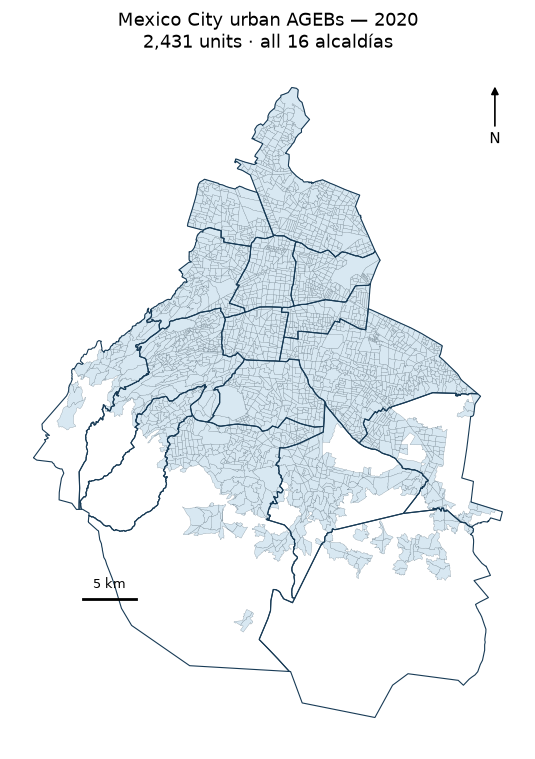

Study-area map: C:\Users\Usuario\merida-urban-intelligence\outputs\maps\00_study_area.png; 2,431 valid AGEBs; 2,348 city-core; 16 alcaldías; 792.1454 km².


In [3]:
from src.transform.geography import run

ageb = run()
assert len(ageb) == 2_431
assert ageb["cvegeo"].is_unique
assert int(ageb["is_city_core"].sum()) == 2_348
assert ageb["mun_name"].nunique() == 16
assert ageb.crs.to_epsg() == 6372
assert ageb.geom_type.eq("MultiPolygon").all()
assert ageb.geometry.is_valid.all()
assert abs(ageb["area_km2"].sum() - 792.15) <= 0.1
assert list(ageb.columns) == [
    "cvegeo", "cve_ent", "cve_mun", "cve_loc", "cve_ageb", "mun_name",
    "loc_name", "is_city_core", "area_km2", "geometry",
]

fig, ax = plt.subplots(figsize=(9, 9))
ageb.plot(ax=ax, facecolor="#d8e8f2", edgecolor="#667985", linewidth=0.18)
municipality_source.boundary.plot(ax=ax, color="#183b56", linewidth=0.8)
ax.set_title("Mexico City urban AGEBs — 2020\n2,431 units · all 16 alcaldías", fontsize=13)
ax.set_axis_off()
ax.annotate(
    "N", xy=(0.94, 0.96), xytext=(0.94, 0.88), xycoords="axes fraction",
    ha="center", va="center", fontsize=11,
    arrowprops={"arrowstyle": "-|>", "color": "black", "lw": 1.2},
)
bounds = ageb.total_bounds
scale_x = bounds[0] + 0.06 * (bounds[2] - bounds[0])
scale_y = bounds[1] + 0.06 * (bounds[3] - bounds[1])
ax.plot([scale_x, scale_x + 5_000], [scale_y, scale_y], color="black", linewidth=2)
ax.text(scale_x + 2_500, scale_y + 800, "5 km", ha="center", va="bottom", fontsize=9)
OUTPUT_MAPS.mkdir(parents=True, exist_ok=True)
map_path = OUTPUT_MAPS / "00_study_area.png"
fig.savefig(map_path, dpi=220, bbox_inches="tight")
plt.show()
plt.close(fig)
assert map_path.exists() and map_path.stat().st_size > 0
print(f"Study-area map: {map_path}; 2,431 valid AGEBs; 2,348 city-core; {ageb.mun_name.nunique()} alcaldías; {ageb.area_km2.sum():.4f} km².")

In [4]:
from src.transform.spatial import assign_ageb, points_from_latlon

denue = pd.read_csv(
    DENUE_PATH,
    encoding="latin-1",
    dtype=str,
    usecols=["id", "latitud", "longitud"],
)
assert len(denue) == 462_732
assert denue["id"].is_unique
sample = denue.sample(n=min(1_000, len(denue)), random_state=2020)
sample_points = points_from_latlon(sample, "latitud", "longitud")
sample_assigned = assign_ageb(sample_points)
print(f"Deterministic DENUE sample: {len(sample_assigned):,} assigned of {len(sample_points):,} valid points.")
assert sample_assigned["id"].is_unique
assert sample_assigned["cvegeo"].notna().all()

# Full-file win condition from TEAM_PLAN §4.4.
denue_points = points_from_latlon(denue, "latitud", "longitud")
denue_assigned = assign_ageb(denue_points)
print(f"Full DENUE acceptance: {len(denue_assigned):,} assigned records; unique IDs={denue_assigned['id'].is_unique}.")
assert len(denue_assigned) == 461_231
assert denue_assigned["id"].is_unique
assert denue_assigned["cvegeo"].notna().all()

Dropped 0 invalid/out-of-study-area coordinates from 1000 rows.


kept 997 / 1000 (99.7%)
Deterministic DENUE sample: 997 assigned of 1,000 valid points.


Dropped 3 invalid/out-of-study-area coordinates from 462732 rows.


kept 461231 / 462729 (99.7%)


Full DENUE acceptance: 461,231 assigned records; unique IDs=True.


## Assessment result and acceptance

The source layers have projected metre coordinates and are normalized to EPSG:6372; their source WKT does not resolve to an EPSG authority code. The three `CVEGEO` keys are 13/9/5 characters for AGEB/locality/alcaldía and decompose as state + municipality + locality + AGEB. All state-09 source geometries are valid. The output `ageb.parquet` contains exactly the ten columns in TEAM_PLAN §3.2, 2,431 unique valid MultiPolygons in EPSG:6372, 2,348 city-core AGEBs across 16 alcaldías, and 792.1454 km² measured from projected geometry. The map is written to `outputs/maps/00_study_area.png`.

The UTF-8-independent `latin-1` DENUE read and strict `within` spatial join pass the sample and full-state acceptance checks: 461,231 establishments assigned with unique IDs and no duplicate join rows. Invalid/out-of-bbox coordinates and valid points outside every AGEB are reported separately by the shared spatial API and are not assigned.

Raw data is read-only. Only the map and processed GeoParquet are written by this notebook.